# grid_stat_merge 说明

格站融合：用站点相对格点的偏差，按高斯权重订正网格场。

**融合格点 = 原格点 + 偏差场**

## 1. 算法原理

1. **站点偏差**：格点线性插到站后与观测作差  
   `bias = 站值 − 格点插站值`。
2. **高斯传播**：各站 bias 以二维高斯核（半径 `R`，`σ≈0.35·R`，水平约 `R×0.01°`）累加到网格并按权重归一，得到偏差场。
3. **可选约束**：地形 `|Δh|<100 m` 掩膜；热传导迭代平滑去“牛眼”。
4. **写回**：`融合格点 = 原格点 + 偏差场`。

## 2. 算法实现方式

| 层级 | 路径 | 说明 |
|------|------|------|
| 算法核 | `src/grid_stat_merge.py` | `do_gs_merge` / `diffuse_values` / `GridStatMergePlugin` |
| 调度 | `src/runner.py` | `process`：读写 Micaps → 融合 |
| 配置 | `src/utils/util_env.py` | `resource/grid_stat_merge.ini` |
| CLI | `cli/__main__.py` | argparse → `process` |

主流程：插站算 bias → 高斯核累加归一 →（可选）热传导 → 加到原格点。  
入参为 meteva 格点 + 站点 DataFrame。

In [ ]:
from pathlib import Path
import sys

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from utils.util_env import get_merge_params, get_resolved_paths

print("路径:", get_resolved_paths())
print("融合参数:", get_merge_params())

## 3. 算法参数说明

| 参数 | ini | CLI | 默认 | 含义 |
|------|-----|-----|------|------|
| `R` | `R` | `--R` | 200 | 误差传播半径 |
| `domain` | `domain` | `--domain` | 空→从格点推断 | `sou,nor,wst,est,dlon,dlat` |
| 地形 | `terr_path` | `--terr` | 无 | 启用高差掩膜 |
| 热传导 | `use_heatflux` | `--use-heatflux` | false | 去牛眼 |
| 迭代 | `hf_eq_iter_nums` | `--hf-iters` | 20 | 热传导次数 |
| 站点列 | `sta_val_col` 等 | — | `data0/lon/lat` | 列名 |

路径键：`grid_path` / `sta_path` / `output_path` / `grid_type` / `sta_type`。未传 CLI 项读 ini。

## 4. 算法使用说明

1. 在 `resource/grid_stat_merge.ini` 填写 `grid_path`、`sta_path` 等。  
2. 仓库根执行 CLI，或模块调用 / 直跑 `python src/runner.py`。  
3. 输出默认 `resource/output/merge.m4`。

模块示例：

```python
from runner import process
process(grid_path="a.m4", sta_path="b.m3", output_path="out.m4", R=200)
```

## 5. CLI 调用说明

在仓库根（`grid_stat_merge/`）执行：

```bash
python -m cli --help
python -m cli
python -m cli --grid=a.m4 --sta=b.m3 --output=out.m4
python -m cli --R=200 --use-heatflux false
python -m cli --domain=20,50,70,140,0.1,0.1 --terr=terr.m4 --hf-iters=20
```

| 参数 | 说明 |
|------|------|
| `--grid` / `--sta` / `--output` | 输入输出路径 |
| `--terr` | 可选地形 |
| `--R` | 传播半径 |
| `--domain` | 业务域六元组 |
| `--use-heatflux` / `--hf-iters` | 热传导开关与迭代 |

更完整说明见 `docs/grid_stat_merge_程序说明.md`。

## 6. 示例：2m 温度格站融合

ECMWF `TMP_2M` 格点（NC）+ 全国关测气温（Micaps3）→ `do_gs_merge`，对比订正前后填色图并写出 Micaps4。

图片已保存至D:\Work\NIMM_pip_repos_tmp\grid_stat_merge\nbs\tmp2m_before.png
图片已保存至D:\Work\NIMM_pip_repos_tmp\grid_stat_merge\nbs\tmp2m_after.png


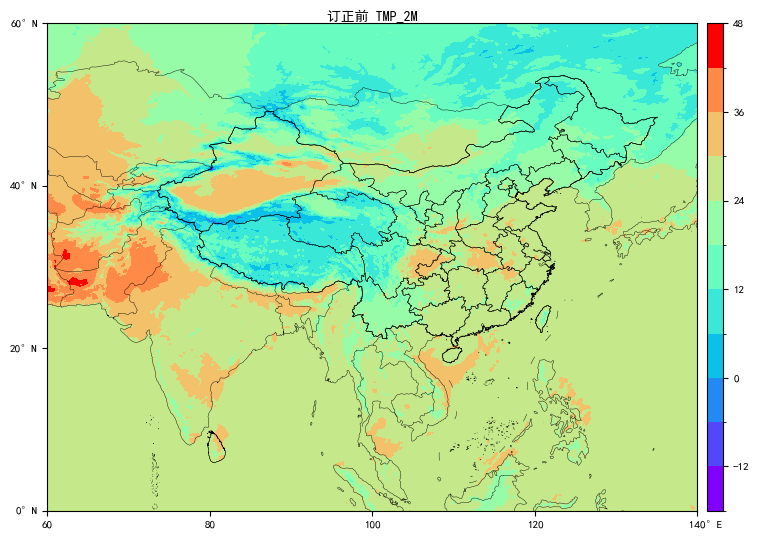

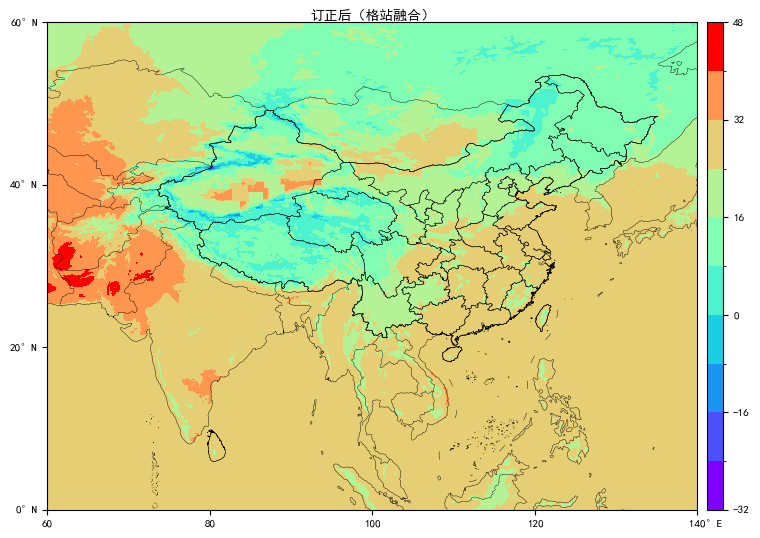

OK → D:\Work\NIMM_pip_repos_tmp\grid_stat_merge\resource\output\tmp2m_gs_merge.m4


In [2]:
%matplotlib inline

from pathlib import Path
import sys

from IPython.display import Image, display

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

import meteva.base as meb
from grid_stat_merge import do_gs_merge

GRID = r"D:\data1\zhongzhuan\20260828\model_RT\globalECMWF_D1D\TMP_2M\2026\20260826\2026082600.012.nc"
STA = r"D:\data1\zhongzhuan\20260828\107_Observation\TEM_national\sfc\20260826\h01_202608262000.m3"
OUT = root / "resource" / "output" / "tmp2m_gs_merge.m4"
FIG_DIR = Path(".").resolve()

grd = meb.read_griddata_from_nc(GRID)
sta = meb.read_stadata_from_micaps3(STA)
out = do_gs_merge(grd, sta, R=100, sta_val_col="data0")

fig_before = FIG_DIR / "tmp2m_before.png"
fig_after = FIG_DIR / "tmp2m_after.png"
meb.plot_tools.contourf_2d_grid(grd, save_path=str(fig_before), title="订正前 TMP_2M", show=False, dpi=100)
meb.plot_tools.contourf_2d_grid(out, save_path=str(fig_after), title="订正后（格站融合）", show=False, dpi=100)
display(Image(filename=str(fig_before)))
display(Image(filename=str(fig_after)))

OUT.parent.mkdir(parents=True, exist_ok=True)
meb.write_griddata_to_micaps4(out, str(OUT), creat_dir=True)
print("OK →", OUT)